In [1]:
import numpy as np
import xarray as xr

from eofs.xarray import Eof

In [2]:
import os

import glob

In [3]:
from pathlib import Path

cwd = Path.cwd()
era5_dir = cwd.parents[6]

# build a path relative to two-up:
gh_dir = era5_dir / 'shared_data/Datasets/ERA5/plev'

1. compute monthly zeof

In [99]:
ilev = 1000 # Pa

def pre(ds): return ds[['var129']].sel(lat=slice(-20,-90)).sel(plev=ilev)

In [100]:
mons = np.arange(6,12+1,1)

In [101]:
gh_fpath = str(gh_dir / f"era5_an_geopot_reg2_6h_*.nc")

gh_6h_mon = xr.open_mfdataset(gh_fpath, preprocess=pre, combine="by_coords", chunks="auto")
gh_6h_mon = gh_6h_mon.sel(time=slice('1979-01-01', '2023-12-31'))  # years 1979–2023

In [102]:
mon = 6

In [127]:
# pick the month then average within each year -> (year, lat, lon)
z_mon = (
    gh_6h_mon['var129']
    .where(gh_6h_mon['time'].dt.month == mon, drop=True)
    .groupby('time.year').mean('time')
)

pwt_mon = (z_mon / 9.8)

w  = np.sqrt(np.cos(np.deg2rad(pwt_mon['lat'])))
# cosine weight anomalies
da_wgt = pwt_mon*w

clim = da_wgt.mean('year')
pwt_anom = da_wgt - clim

da = pwt_anom.rename(year='time').transpose('time', 'lat', 'lon').astype('float32').compute()

In [132]:
def eof(X,n=-1,detrend='constant',eof_in=None):
	"""Principal Component Analysis / Empirical Orthogonal Functions / SVD

		Uses Singular Value Decomposition to find the dominant modes of variability.
		The field X can be reconstructed with Y = dot(EOF,PC) + X.mean(axis=time)

		INPUTS:
			X	-- Field, shape (time x space).
			n	-- Number of modes to extract. All modes if n < 0
			detrend -- detrend with global mean ('constant')
						  or linear trend ('linear')
		    eof_in  -- If not None, compute PC by projecting eof onto X.
		OUTPUTS:
			EOF - Spatial modes of variability
			PC  - Temporal evolution of EOFs - only output if eof_in is not None
			E   - Explained value of variability
			u   - spatial modes
			s   - variances
			v   - temporal modes
	"""
	is_xr = False
	try:
		import xarray as xr
		if isinstance(X,xr.DataArray):
			is_xr = True
			dims = []
			for dim in X.dims[1:]:
				dims.append(X[dim])
			tdim = [X[X.dims[0]]]
			X = X.values
	except:
		pass
	import scipy.signal as sg
	# make sure we have a matrix time x space
	shpe = X.shape
	if len(shpe) > 2:
		X = X.reshape([shpe[0],np.prod(shpe[1:])])
		if eof_in is not None:
			if len(eof_in.shape) > 2:
				eof_in = eof_in.reshape([np.prod(eof_in.shape[:-1]),eof_in.shape[-1]])
			else:
				eof_in = eof_in.reshape([np.prod(eof_in.shape),1])
	# take out the time mean or trend
	X = sg.detrend(X.transpose(),type=detrend)
	if eof_in is not None:
		if eof_in.shape[-1] == X.shape[0]:
			PC =  np.matmul(eof_in, X)
			eof_norm = np.dot(eof_in.transpose(),eof_in)
			return np.dot(PC,np.linalg.inv(eof_norm))
		else:
			PC = np.matmul(eof_in.transpose(), X)
			eof_norm = np.dot(eof_in.transpose(),eof_in)
			return np.dot(PC.transpose(),np.linalg.inv(eof_norm)).transpose()
		# return sg.detrend(PC,type='constant')
	# perform SVD - v is actually V.H in X = U*S*V.H
	u,s,v = np.linalg.svd(X, full_matrices=False)
	# now, u contains the spatial, and v the temporal structures
	# s contains the variances, with the same units as the input X
	# u.shape = (space, modes(space)), v.shape = (modes(space), time)

	# get the first n modes, in physical units
	#  we can either project the data onto the principal component, X*V
	#  or multiply u*s. This is the same, as U*S*V.H*V = U*S
	if n < 0:
		n = s.shape[0]
	EOF = np.dot(u[:,:n],np.diag(s)[:n,:n])
	# time evolution is in v
	PC  = v[:n,:]
	# EOF wants \lambda = the squares of the eigenvalues,
	#  but SVD yields \gamma = \sqrt{\lambda}
	s2 = s*s
	E   = s2[:n]/sum(s2)
	# now we need to make sure we get everything into the correct shape again
	u = u[:,:n]
	s = s[:n]
	v = v.transpose()[:,:n]
	if len(shpe) > 2:
		# replace time dimension with modes at the end of the array
		newshape = list(shpe[1:])+[n]
		EOF = EOF.reshape(newshape)
		u   = u	 .reshape(newshape)
	if is_xr: # return xarray dataarrays
		mode = [('n',np.arange(1,n+1))]
		EOF = xr.DataArray(EOF,coords=dims+mode,name='EOF')
		PC  = xr.DataArray(PC,coords=tdim+mode,name='PC')
		E   = xr.DataArray(E,coords=mode,name='E')
	return EOF,PC,E,u,s,v

In [170]:
da_clean = da.fillna(0.0)

eof_map, pc_ts, expl_var, u, s, v = eof(da_clean, detrend='constant')

In [214]:
u.shape

(36, 180, 45)

In [171]:
eof1 = eof_map.sel(n=1)

eof_physical = eof1#/ w

In [172]:
# 5. Sign Check (Match NCL logic)
# NCL checked if (60S, 90E) was negative.
check_lat = -60
check_lon = 90
# Find nearest point
val = eof_physical.sel(lat=check_lat, lon=check_lon, method='nearest').values

if val < 0:
    eof_physical = eof_physical * -1.0

In [173]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

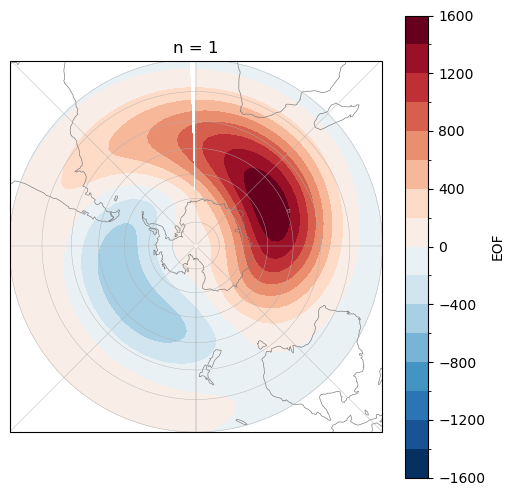

In [216]:
proj = ccrs.SouthPolarStereo()
fig = plt.figure(figsize=(6, 6))
ax = plt.axes(projection=proj)
ax.set_extent([-180, 180, -90, -20], ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="gray")
ax.gridlines(draw_labels=False, xlocs=np.arange(-180, 181, 45),
             ylocs=np.arange(-90, -19, 10), linewidth=0.3)

# filled contours
h = eof_physical.plot.contourf(ax=ax, transform=ccrs.PlateCarree(),
                     levels=21, add_colorbar=True)

In [231]:
np.sum(u_da**2)

<xarray.DataArray 'Eigenvector 1' ()> Size: 4B
array(0.99999994, dtype=float32)

In [217]:
# 1. Select Mode 1 (index 0 in Python)
# u usually has shape (lat, lon, modes) based on your function
u_mode1 = u[:, :, 0]

# 2. Wrap it in an xarray.DataArray
# 'da_wgt' or 'z_mon' is your original data object used to get lat/lon
u_da = xr.DataArray(
    u_mode1, 
    coords={'lat': da_wgt.lat, 'lon': da_wgt.lon}, 
    dims=('lat', 'lon'),
    name='Eigenvector 1'
)

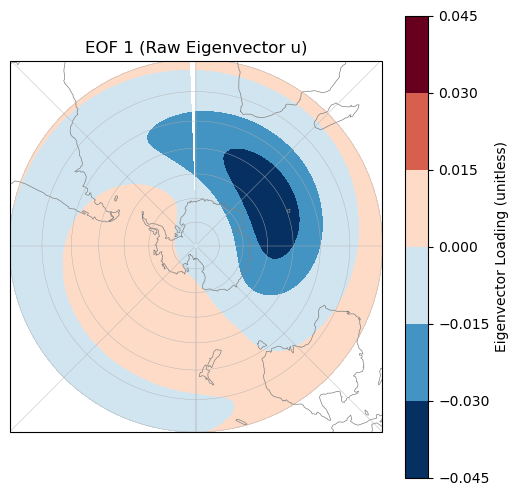

In [218]:
# Define Projection
proj = ccrs.SouthPolarStereo()

fig = plt.figure(figsize=(6, 6))
ax = plt.axes(projection=proj)

# Set Extent (SH)
ax.set_extent([-180, 180, -90, -20], ccrs.PlateCarree())

# Add Features
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="gray")
ax.gridlines(draw_labels=False, xlocs=np.arange(-180, 181, 45),
             ylocs=np.arange(-90, -19, 10), linewidth=0.3)

# --- PLOT THE EIGENVECTOR (u) ---
# Note: 'u' values are usually very small (e.g., 0.02) because 
# the vector is normalized to length 1. 
# We don't specify levels manually so it auto-scales, or we use a tight range.

h = u_da.plot.contourf(
    ax=ax, 
    transform=ccrs.PlateCarree(),
    cmap="RdBu_r",           # Red-Blue colormap is standard for EOFs
    center=0,                # Centers white on 0
    cbar_kwargs={'label': 'Eigenvector Loading (unitless)'} # Label the bar
)

plt.title("EOF 1 (Raw Eigenvector u)")
plt.show()

In [240]:
eof1

<xarray.DataArray 'EOF' (lat: 36, lon: 180)> Size: 26kB
array([[ 5.99356651e+01,  6.09910355e+01,  6.23735275e+01, ...,
         5.51869888e+01,  5.70962906e+01,  5.86962700e+01],
       [ 2.68454990e+01,  2.80159092e+01,  2.93475609e+01, ...,
         2.11953430e+01,  2.33764114e+01,  2.52862301e+01],
       [-2.14787560e+01, -2.02220058e+01, -1.88924065e+01, ...,
        -2.71133232e+01, -2.50608120e+01, -2.31840267e+01],
       ...,
       [-1.05291725e+02, -1.06600723e+02, -1.07901833e+02, ...,
        -1.01341827e+02, -1.02660271e+02, -1.03977722e+02],
       [-7.38907242e+01, -7.43447495e+01, -7.47973175e+01, ...,
        -7.25127563e+01, -7.29731522e+01, -7.34319687e+01],
       [-2.61918581e-06, -2.61918581e-06, -2.61918581e-06, ...,
        -2.61918581e-06, -2.61918581e-06, -2.61918581e-06]], dtype=float32)
Coordinates:
  * lat      (lat) float64 288B -20.0 -22.0 -24.0 -26.0 ... -86.0 -88.0 -90.0
  * lon      (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
    n        int64 8B 1

In [241]:
anom_mon

<xarray.DataArray (time: 1350, lat: 36, lon: 180)> Size: 70MB
dask.array<where, shape=(1350, 36, 180), dtype=float64, chunksize=(27, 36, 180), chunktype=numpy.ndarray>
Coordinates:
  * lon        (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
  * lat        (lat) float64 288B -20.0 -22.0 -24.0 -26.0 ... -86.0 -88.0 -90.0
    plev       (time) float64 11kB 1e+03 1e+03 1e+03 1e+03 ... 1e+03 1e+03 1e+03
  * time       (time) datetime64[ns] 11kB 1979-06-01 1979-06-02 ... 2023-06-30
    dayofyear  (time) int64 11kB 152 153 154 155 156 157 ... 177 178 179 180 181

- projection

In [196]:
# for mon in mons:
# print(mon)
gh_fpath = str(gh_dir / f"era5_an_geopot_reg2_6h_*.nc")

gh_6h_mon = xr.open_mfdataset(gh_fpath, preprocess=pre, combine="by_coords", chunks="auto")
gh_6h_mon = gh_6h_mon.sel(time=slice('1979-01-01', '2023-12-31'))  # years 1979–2023

gh_day_mon = gh_6h_mon['var129'].resample(time="1D").mean()

# Convert to meters
z_m = gh_day_mon / 9.8

# Compute climatology in meters
z_clim = z_m.groupby("time.dayofyear").mean("time")

# Compute anomalies (unweighted)
z_anom = z_m.groupby("time.dayofyear") - z_clim

# THEN apply weights
w = np.cos(np.deg2rad(z_anom['lat']))


/usr/local/Miniconda3-envs/envs/2024/envs/iacpy3_2024/lib/python3.11/site-packages/xarray/core/indexing.py:1593: PerformanceWarning: Slicing with an out-of-order index is generating 45 times more chunks
  return self.array[key]


In [197]:
z_anom_wgt = z_anom*np.sqrt(w)

anom_mon = z_anom_wgt.where(z_anom_wgt['time'].dt.month==6, drop=True)

In [232]:
# ds_anom: (year, day, lat, lon)
# eof1: (lat, lon)
pc_raw = anom_mon.dot(-1*u_da, dims=('lat', 'lon'))

In [233]:
# 6. Standardization (FIX: Match NCL's dim_standardize_n_Wrap(ts,1,0))
# NCL standardizes each calendar day (0..365) separately across years.
# We use groupby('day') to normalize June 1sts relative to other June 1sts.
def standardize(x):
    return (x - x.mean()) / x.std()

pc_std = pc_raw.groupby("time.day").map(standardize)

In [234]:
pc_raw

<xarray.DataArray (time: 1350)> Size: 11kB
dask.array<sum-aggregate, shape=(1350,), dtype=float64, chunksize=(27,), chunktype=numpy.ndarray>
Coordinates:
    plev       (time) float64 11kB 1e+03 1e+03 1e+03 1e+03 ... 1e+03 1e+03 1e+03
  * time       (time) datetime64[ns] 11kB 1979-06-01 1979-06-02 ... 2023-06-30
    dayofyear  (time) int64 11kB 152 153 154 155 156 157 ... 177 178 179 180 181

In [222]:
# 4. Standardize (if needed, to match NCL)
pc_final = (pc_raw - pc_raw.mean()) / pc_raw.std()

In [223]:
pc_final[150:]

<xarray.DataArray (time: 1200)> Size: 10kB
dask.array<getitem, shape=(1200,), dtype=float64, chunksize=(27,), chunktype=numpy.ndarray>
Coordinates:
    plev       (time) float64 10kB 1e+03 1e+03 1e+03 1e+03 ... 1e+03 1e+03 1e+03
  * time       (time) datetime64[ns] 10kB 1984-06-01 1984-06-02 ... 2023-06-30
    dayofyear  (time) int64 10kB 153 154 155 156 157 158 ... 177 178 179 180 181

In [224]:
pc_std[:30].values

array([ 0.22044519,  0.1553681 ,  0.23997814,  0.32206101,  0.16674784,
       -0.12437488, -0.16046116,  0.07489679,  0.26817508,  0.22140348,
        0.17812323,  0.30429622,  0.33085313,  0.25428468,  0.14920005,
        0.03483382,  0.02320727,  0.16982878,  0.08634717, -0.13065484,
       -0.3057934 , -0.28234642, -0.03113953,  0.20738459,  0.27783727,
        0.15191155,  0.04897082, -0.30607991, -0.71789655, -1.12742732])

In [235]:
pc_std.sel(time="1979").values[:5]

array([-0.22044519, -0.1553681 , -0.23997814, -0.32206101, -0.16674784])

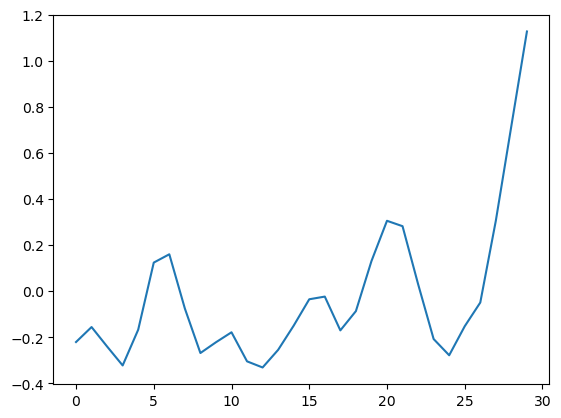

In [237]:
plt.plot(pc_std.sel(time="1979").values[:30])

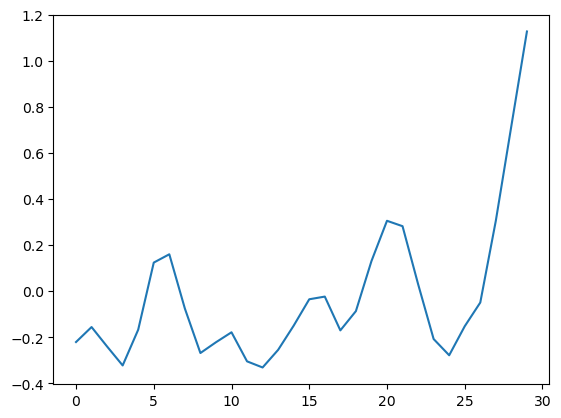

In [238]:
plt.plot(pc_std[:30])

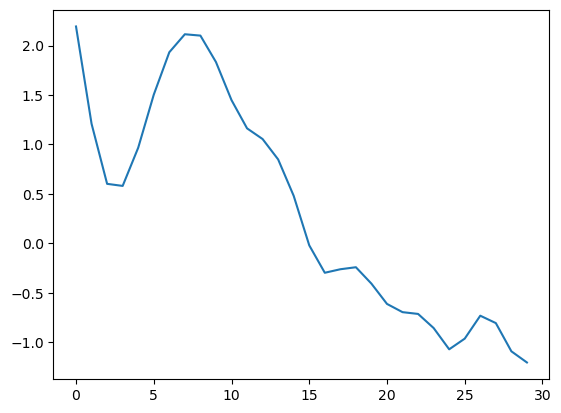

In [239]:
plt.plot(pc_std[150:180])

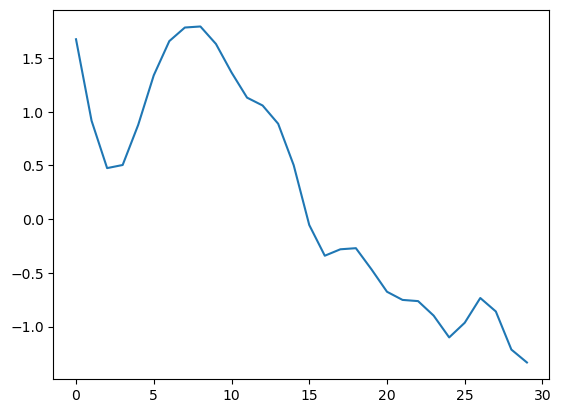

In [206]:
plt.plot(pc_final[150:180])